In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
from datetime import datetime
import os

# 1. 벅스 차트 크롤링
- 실시간, 100개
- url : https://music.bugs.co.kr/chart
- 곡명, 아티스트명
- 결과는 아래 예시와 같이 차트 순서대로 List[Dict] 로 담기 → 변수명 **bugs_chart_list**

```python
[
    {'title': '갑자기', 'artists': '아이오아이(I.O.I)'},
    {'title': 'LEMONADE', 'artists': 'aespa'},
    {'title': 'REDRED', 'artists': 'CORTIS (코르티스)'},
    ...
]
```

In [38]:
url = "https://music.bugs.co.kr/chart"

headers = {
    "Referer": url,
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
response

soup = BeautifulSoup(response.text, 'html.parser')

# 인기차트
bugs_chart = soup.select("table.byChart > tbody > tr")
len(bugs_chart)

bugs_chart_list = []
for music in bugs_chart:
    # 타이틀
    title_el = music.select_one("th p.title a")
    title = title_el.text.strip() if title_el else ""
    
    # 아티스트
    artist_el = music.select_one("td p.artist a")
    artist = artist_el.text.strip() if artist_el else ""

    bugs_chart_list.append({
        "title": title,
        "artist": artist
    })
    
print(len(bugs_chart_list))
bugs_chart_list  # ✅최종적으로 보여주기

100


[{'title': '갑자기', 'artist': '아이오아이(I.O.I)'},
 {'title': 'LEMONADE', 'artist': 'aespa'},
 {'title': 'REDRED', 'artist': 'CORTIS (코르티스)'},
 {'title': 'It′s Me', 'artist': '아일릿(ILLIT)'},
 {'title': 'WDA (Whole Different Animal) (Feat. G-DRAGON)', 'artist': 'aespa'},
 {'title': 'LOVE ATTACK', 'artist': 'RESCENE (리센느)'},
 {'title': '소문의 낙원', 'artist': 'AKMU(악뮤)'},
 {'title': 'Heavy Serenade', 'artist': 'NMIXX'},
 {'title': '기쁨, 슬픔, 아름다운 마음', 'artist': 'AKMU(악뮤)'},
 {'title': '0+0', 'artist': '한로로'},
 {'title': '사랑하게 될 거야', 'artist': '한로로'},
 {'title': 'Drowning', 'artist': 'WOODZ'},
 {'title': '캐치 캐치', 'artist': 'YENA (최예나)'},
 {'title': 'BOOMPALA', 'artist': 'LE SSERAFIM (르세라핌)'},
 {'title': 'RUDE!', 'artist': 'Hearts2Hearts (하츠투하츠)'},
 {'title': '404 (New Era)', 'artist': 'KiiiKiii (키키)'},
 {'title': 'Popcorn', 'artist': '도경수(D.O.)'},
 {'title': 'Good Goodbye', 'artist': '화사 (HWASA)'},
 {'title': '입춘', 'artist': '한로로'},
 {'title': 'Baby Flower', 'artist': 'tripleS (트리플에스)'},
 {'title': 'B

# 2. 멜론 차트 크롤링
- 실시간, 100개
- url : https://www.melon.com/chart/index.htm
- 곡명, 아티스트명
- 결과는 아래 예시와 같이 차트 순서대로 List[Dict] 로 담기 → 변수명 **melon_chart_list**

```python
[
    {'title': '갑자기', 'artists': '아이오아이(I.O.I)'},
    {'title': 'LEMONADE', 'artists': 'aespa'},
    {'title': 'REDRED', 'artists': 'CORTIS (코르티스)'},
    ...
]
```

In [80]:
url = "https://www.melon.com/chart/index.htm"

headers = {
    "Referer": url,
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
response

soup = BeautifulSoup(response.text, 'html.parser')


# 인기차트
melon_chart = soup.select("div.d_song_list > table > tbody > tr")
len(melon_chart)
melon_chart

melon_chart_list = []
for music in melon_chart:
    # 타이틀
    title_el = music.select_one("td > div > div > div.rank01 > span > a")
    title = title_el.text.strip()  if artist_el else ""
    
    # 아티스트
    artist_el = music.select_one("td > div > div > div.ellipsis.rank02 > a")
    artist = artist_el.text.strip().replace('\xa0', ' ') if artist_el else ""

    melon_chart_list.append({
        "title": title,
        "artist": artist
    })
    
print(len(melon_chart_list))
melon_chart_list  # ✅최종적으로 보여주기

100


[{'title': '갑자기', 'artist': '아이오아이 (I.O.I)'},
 {'title': 'REDRED', 'artist': 'CORTIS (코르티스)'},
 {'title': 'It′s Me', 'artist': '아일릿(ILLIT)'},
 {'title': '소문의 낙원', 'artist': 'AKMU (악뮤)'},
 {'title': 'LEMONADE', 'artist': 'aespa'},
 {'title': '기쁨, 슬픔, 아름다운 마음', 'artist': 'AKMU (악뮤)'},
 {'title': '캐치 캐치', 'artist': 'YENA (최예나)'},
 {'title': 'RUDE!', 'artist': 'Hearts2Hearts (하츠투하츠)'},
 {'title': '사랑하게 될 거야', 'artist': '한로로'},
 {'title': 'Heavy Serenade', 'artist': 'NMIXX'},
 {'title': 'Drowning', 'artist': 'WOODZ'},
 {'title': 'WDA (Whole Different Animal) (Feat. G-DRAGON)', 'artist': 'aespa'},
 {'title': '0+0', 'artist': '한로로'},
 {'title': '404 (New Era)', 'artist': 'KiiiKiii (키키)'},
 {'title': 'BANG BANG', 'artist': 'IVE (아이브)'},
 {'title': 'Good Goodbye', 'artist': '화사 (HWASA)'},
 {'title': 'SWIM', 'artist': '방탄소년단'},
 {'title': 'LOVE ATTACK', 'artist': 'RESCENE (리센느)'},
 {'title': '타임캡슐', 'artist': '다비치'},
 {'title': 'Popcorn', 'artist': '도경수(D.O.)'},
 {'title': '너에게 닿기를', 'artist': '

# 3. 지니 차트 크롤링
- 실시간, 100개
- url : https://www.genie.co.kr/chart/top200
- 곡명, 아티스트명
- 결과는 아래 예시와 같이 차트 순서대로 List[Dict] 로 담기 → 변수명 **genie_chart_list**

```python
[
    {'title': '갑자기', 'artists': '아이오아이(I.O.I)'},
    {'title': 'LEMONADE', 'artists': 'aespa'},
    {'title': 'REDRED', 'artists': 'CORTIS (코르티스)'},
    ...
]
```

In [81]:
url = "https://www.genie.co.kr/chart/top200"

headers = {
    "Referer": url,
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
response

soup = BeautifulSoup(response.text, 'html.parser')


# 인기차트
genie_chart = soup.select("div.music-list-wrap > table.list-wrap > tbody > tr")
len(genie_chart)
genie_chart

genie_chart_list = []
for music in genie_chart:
    # 타이틀
    title_el = music.select_one("td > a.title.ellipsis")
    title = title_el.text.strip() if artist_el else ""
    
    # 아티스트
    artist_el = music.select_one("td.info > a.artist.ellipsis")
    artist = artist_el.text.strip() if artist_el else ""

    genie_chart_list.append({
        "title": title,
        "artist": artist
    })
    
url = "https://www.genie.co.kr/chart/top200?ditc=D&ymd=20260605&hh=10&rtm=Y&pg=2"
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')
genie_chart = soup.select("div.music-list-wrap > table.list-wrap > tbody > tr")
for music in genie_chart:
    # 타이틀
    title_el = music.select_one("td > a.title.ellipsis")
    title = title_el.text.strip() if artist_el else ""
    
    # 아티스트
    artist_el = music.select_one("td.info > a.artist.ellipsis")
    artist = artist_el.text.strip() if artist_el else ""

    genie_chart_list.append({
        "title": title,
        "artist": artist
    })

print(len(genie_chart_list))
genie_chart_list  # ✅최종적으로 보여주기

100


[{'title': '갑자기', 'artist': '아이오아이 (I.O.I)'},
 {'title': "It's Me", 'artist': '아일릿(ILLIT)'},
 {'title': '소문의 낙원', 'artist': 'AKMU (악뮤)'},
 {'title': 'REDRED', 'artist': 'CORTIS (코르티스)'},
 {'title': '캐치 캐치', 'artist': 'YENA (최예나)'},
 {'title': '기쁨, 슬픔, 아름다운 마음', 'artist': 'AKMU (악뮤)'},
 {'title': 'Drowning', 'artist': 'WOODZ'},
 {'title': '사랑하게 될 거야', 'artist': '한로로'},
 {'title': '0＋0', 'artist': '한로로'},
 {'title': 'BANG BANG', 'artist': 'IVE (아이브)'},
 {'title': 'Good Goodbye', 'artist': '화사 (HWASA)'},
 {'title': '404 (New Era)', 'artist': 'KiiiKiii (키키)'},
 {'title': 'Popcorn', 'artist': '도경수 (D.O.)'},
 {'title': '타임캡슐', 'artist': '다비치'},
 {'title': 'RUDE!', 'artist': 'Hearts2Hearts (하츠투하츠)'},
 {'title': '멸종위기사랑', 'artist': '이찬혁'},
 {'title': 'LEMONADE', 'artist': 'aespa'},
 {'title': '너에게 닿기를', 'artist': '10CM'},
 {'title': 'WDA (Whole Different Animal) (Feat. G-DRAGON)', 'artist': 'aespa'},
 {'title': '뛰어(JUMP)', 'artist': 'BLACKPINK'},
 {'title': '내게 사랑이 뭐냐고 물어본다면', 'artist': '로이킴'}

# 4. 크롤링 결과를 파일로 저장하기
- 3개 음원사이트 TOP100 결과를 하나의 DataFrame 으로 합치기
- '곡명'만 저장
- 컬럼명은 '벅스', 멜론', '지니'
- 인덱스명은 '순위'
- 합쳐진 DataFrame 은 **result_df** 변수에 담고 결과 보여주세요
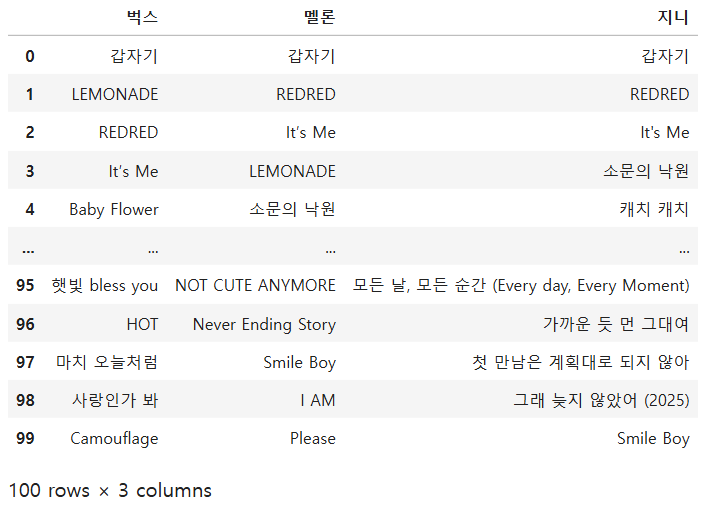



- 위 DataFrame 을 엑셀파일로 저장 , 날짜시간을 사용한 파일명으로 저장
    - 파일명형식 : "음원순위yyyymmddHHMMss.xlsx"
    - ex) 음원순위20210524131122.xlsx


[저장한 엑셀파일 예시]
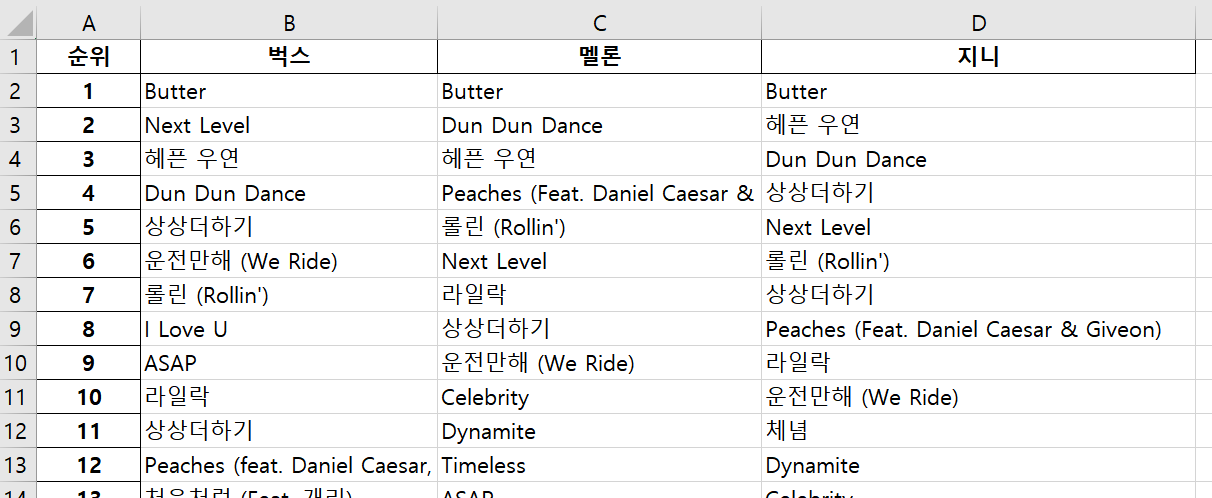

### 4_1  DataFrame 합치기
- 3개 음원사이트 TOP100 결과를 하나의 DataFrame 으로 합치기
- '곡명'만 저장
- 컬럼명은 '벅스', 멜론', '지니'
- 인덱스명은 '순위'
- 합쳐진 DataFrame 은 **result_df** 변수에 담고 결과 보여주세요
- 하나의 셀로 작성하세요    

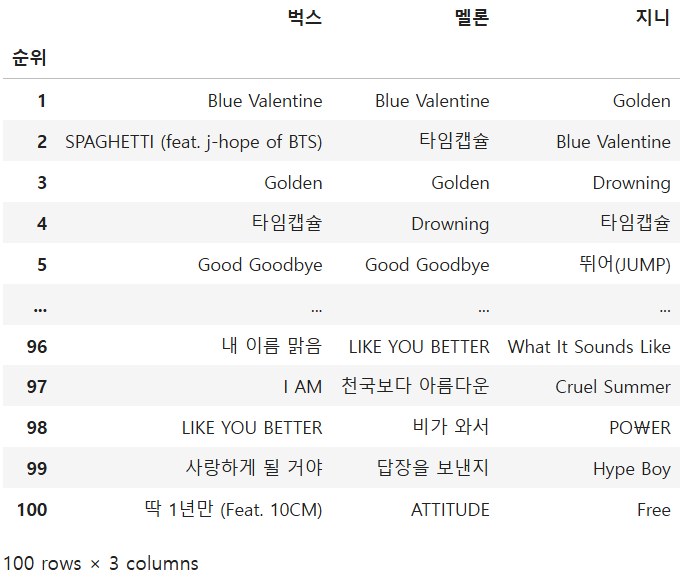

In [54]:
import pandas as pd

result_df = pd.DataFrame({
    "벅스": [music["title"] for music in bugs_chart_list],
    "멜론": [music["title"] for music in melon_chart_list],
    "지니": [music["title"] for music in genie_chart_list]
})

result_df.index = range(1, len(result_df) + 1)
result_df.index.name = "순위"

result_df  # ✅ 결과 보여주세요

,벅스,멜론,지니
순위,,,
1,갑자기,갑자기,갑자기
2,LEMONADE,REDRED,It's Me
3,REDRED,It′s Me,REDRED
4,It′s Me,소문의 낙원,소문의 낙원
5,WDA (Whole Different Animal) (Feat. G-DRAGON),LEMONADE,캐치 캐치
...,...,...,...
96,GO,Smile Boy,TOO BAD (Feat. Anderson .Paak)
97,오늘만 I LOVE YOU,NOT CUTE ANYMORE,SPAGHETTI (Feat. j-hope of BTS)
98,XOXZ,Never Ending Story,Smile Boy


### 4_2 엑셀 파일로 저장하기
- 위 DataFrame 을 엑셀파일로 저장 , 날짜시간을 사용한 파일명으로 저장
- 저장경로 : **{base_path}/data**
- 파일명형식 : **"음원순위yyyymmddHHMMss.xlsx"**
    - ex) 음원순위20210524131122.xlsx
- 하나의 셀로 작성하세요

[저장된 엑셀파일 예시]
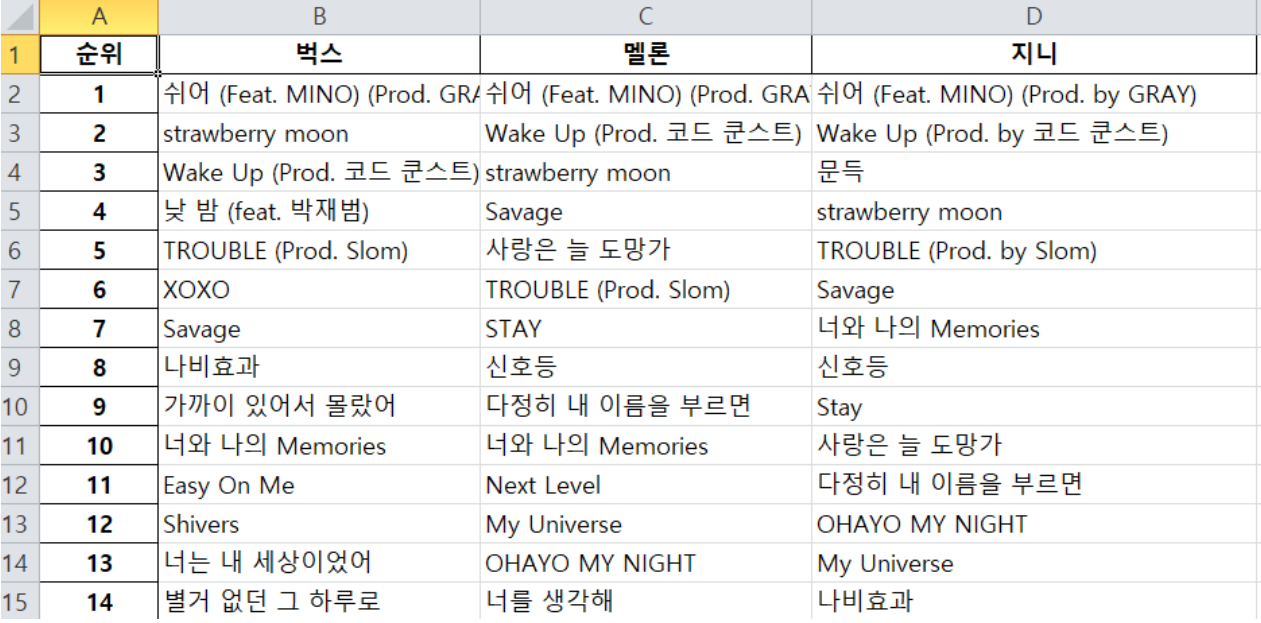

In [55]:
from datetime import datetime
import os

out_path = os.path.join('data')
file_name = f"음원순위{datetime.now().strftime('%Y%m%d%H%M%S')}.xlsx"

if not os.path.exists(out_path):
    os.makedirs(out_path)

with open(os.path.join(out_path, file_name), 'w') as f:
    save_path = os.path.join(out_path, file_name)
    result_df.to_excel(save_path)

In [71]:
# ✅ 확인
# !dir data
# 맥 확인
!ls data

zsh:1: command not found: dir


# 5. 크롤링 결과를 DB 에 저장하기


1. 사용 DataBase 와 계정은 수업시간에 작성한 것으로 합니다.
1. 테이블 작성 DDL
    - 테이블명: **musicchart**

|컬럼명uid|타입|제약조건|설명|
|---|---|---|---|
|id|정수|AI,PK||
|site|문자열|최대20글자, NOT NULL|사이트명(**벅스**, **멜론**, **지니**  중 하나)|
|ranking|정수|NOT NULL, 1이상의 정수|순위|
|title|문자열|최대100글자, NOT NULL|곡명|
|artist|문자열|최대100글자, NOT NULL|가수,아티스트|
|crawl_at|DATETIME|기본값 현재일시|수집한날짜|

    
[INSERT 결과 예시]
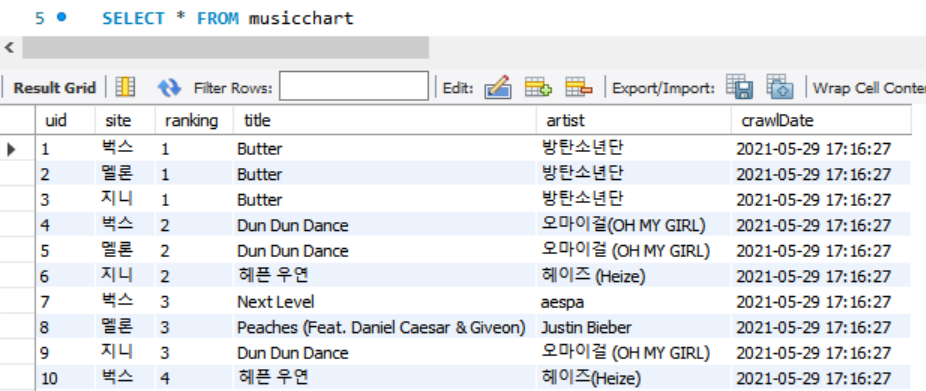

In [57]:
from sqlalchemy import create_engine
from sqlalchemy.orm import DeclarativeBase, sessionmaker
from sqlalchemy import String, Integer, DateTime, CheckConstraint, func
from sqlalchemy.orm import Mapped, mapped_column

In [58]:
DB_USER = 'user2604'
DB_PASSWORD = 1234
DB_HOST = 'localhost'
DB_PORT = 3306
DB_NAME = 'db2604'

DATABASE_URL = (
    f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?charset=utf8mb4"
)

engine = create_engine(DATABASE_URL, echo=True, pool_pre_ping=True)

SessionLocal = sessionmaker(bind=engine, autoflush=False, autocommit=False)

## 5.2 모델 작성 및 생성

In [86]:
class Base(DeclarativeBase):
    pass

class MusicChart(Base):
    __tablename__ = "musicchart"

    id: Mapped[int] = mapped_column(Integer, primary_key=True, autoincrement=True)
    site: Mapped[str] = mapped_column(String(20), nullable=False)
    ranking: Mapped[int] = mapped_column(Integer, CheckConstraint("ranking >= 1"), nullable=False)
    title: Mapped[str] = mapped_column(String(100), nullable=False)
    artist: Mapped[str] = mapped_column(String(100), nullable=False)
    crawl_at: Mapped[DateTime] = mapped_column(DateTime, server_default=func.now())
    
    def __repr__(self):
        return (
            f"<MusicChart(id={self.id}, "
            f"site='{self.site}', "
            f"ranking={self.ranking}, "
            f"title='{self.title}', "
            f"artist='{self.artist}')>"
        )

Base.metadata.drop_all(bind=engine)
Base.metadata.create_all(bind=engine)    
print("✅ 테이블 생성 완료")

2026-06-05 11:41:51,282 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-05 11:41:51,283 INFO sqlalchemy.engine.Engine DESCRIBE `db2604`.`musicchart`
2026-06-05 11:41:51,283 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-05 11:41:51,311 INFO sqlalchemy.engine.Engine 
DROP TABLE musicchart
2026-06-05 11:41:51,311 INFO sqlalchemy.engine.Engine [no key 0.00058s] {}
2026-06-05 11:41:51,334 INFO sqlalchemy.engine.Engine COMMIT
2026-06-05 11:41:51,337 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-05 11:41:51,337 INFO sqlalchemy.engine.Engine DESCRIBE `db2604`.`musicchart`
2026-06-05 11:41:51,337 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-05 11:41:51,339 INFO sqlalchemy.engine.Engine 
CREATE TABLE musicchart (
	id INTEGER NOT NULL AUTO_INCREMENT, 
	site VARCHAR(20) NOT NULL, 
	ranking INTEGER NOT NULL CHECK (ranking >= 1), 
	title VARCHAR(100) NOT NULL, 
	artist VARCHAR(100) NOT NULL, 
	crawl_at DATETIME NOT NULL DEFAULT (now()), 
	PRIMARY KEY (id)
)


2026-06-05 11

## 5.3 크롤링한 음원 차트 저장

In [102]:
def save_chart(site, chart_list = []):
    """벅스 순위 리스트를 저장하고 저장 건수를 반환한다."""
    
    with SessionLocal() as db:
        music_list = []

        ranking = 1
        for music in chart_list:
            music_list.append(
                MusicChart(
                    site=site,
                    ranking=ranking,
                    title=music["title"],
                    artist=music["artist"]
                )
            )
            ranking += 1
        
        db.add_all(music_list)
        db.commit()
        return len(music_list)

In [103]:
# ✅ 저장 실행
save_chart('벅스', bugs_chart_list)
save_chart('멜론', melon_chart_list)
save_chart('지니', genie_chart_list)

2026-06-05 11:46:11,079 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-05 11:46:11,082 INFO sqlalchemy.engine.Engine INSERT INTO musicchart (site, ranking, title, artist) VALUES (%(site)s, %(ranking)s, %(title)s, %(artist)s)
2026-06-05 11:46:11,082 INFO sqlalchemy.engine.Engine [cached since 249.5s ago] {'site': '벅스', 'ranking': 1, 'title': '갑자기', 'artist': '아이오아이(I.O.I)'}
2026-06-05 11:46:11,088 INFO sqlalchemy.engine.Engine INSERT INTO musicchart (site, ranking, title, artist) VALUES (%(site)s, %(ranking)s, %(title)s, %(artist)s)
2026-06-05 11:46:11,089 INFO sqlalchemy.engine.Engine [cached since 249.5s ago] {'site': '벅스', 'ranking': 2, 'title': 'LEMONADE', 'artist': 'aespa'}
2026-06-05 11:46:11,090 INFO sqlalchemy.engine.Engine INSERT INTO musicchart (site, ranking, title, artist) VALUES (%(site)s, %(ranking)s, %(title)s, %(artist)s)
2026-06-05 11:46:11,090 INFO sqlalchemy.engine.Engine [cached since 249.5s ago] {'site': '벅스', 'ranking': 3, 'title': 'REDRED', 'artist': 'CORT

100

## 5.4 읽어와서 출력하기

In [104]:
# DB 읽어와서 모델을 그대로 출력하세요
"""
[예시]
<MusicChart(id=1, site='벅스', ranking=1, title='갑자기', artist='아이오아이(I.O.I)')>
<MusicChart(id=2, site='벅스', ranking=2, title='LEMONADE', artist='aespa')>
<MusicChart(id=3, site='벅스', ranking=3, title='IF I', artist='TREASURE(트레저)')>
<MusicChart(id=4, site='벅스', ranking=4, title='REDRED', artist='CORTIS (코르티스)')>
...
"""

from sqlalchemy import select

def print_music_chart(db, site):
    
    stmt = (
        select(MusicChart)
        .where(MusicChart.site == site)
        .order_by(MusicChart.ranking)
    )
    return db.scalars(stmt).all()


if __name__ == "__main__":
    """위 동작들을 실행하는 코드들을 작성해보세요"""
    with SessionLocal() as db:
        print("== 🟡 벅스 차트 조회 ==")
        for chart in print_music_chart(db, "벅스"):
            print(chart)
        
        # print("== 🟡 멜론 차트 조회 ==")
        # for chart in print_music_chart(db, "멜론"):
        #     print(chart)
        
        # print("== 🟡 지니 차트 조회 ==")
        # for chart in print_music_chart(db, "지니"):
        #     print(chart)

== 🟡 벅스 차트 조회 ==
2026-06-05 11:46:21,676 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-05 11:46:21,678 INFO sqlalchemy.engine.Engine SELECT musicchart.id, musicchart.site, musicchart.ranking, musicchart.title, musicchart.artist, musicchart.crawl_at 
FROM musicchart 
WHERE musicchart.site = %(site_1)s ORDER BY musicchart.ranking
2026-06-05 11:46:21,681 INFO sqlalchemy.engine.Engine [cached since 256.2s ago] {'site_1': '벅스'}
<MusicChart(id=1, site='벅스', ranking=1, title='갑자기', artist='아이오아이(I.O.I)')>
<MusicChart(id=301, site='벅스', ranking=1, title='갑자기', artist='아이오아이(I.O.I)')>
<MusicChart(id=601, site='벅스', ranking=1, title='갑자기', artist='아이오아이(I.O.I)')>
<MusicChart(id=701, site='벅스', ranking=1, title='갑자기', artist='아이오아이(I.O.I)')>
<MusicChart(id=801, site='벅스', ranking=1, title='갑자기', artist='아이오아이(I.O.I)')>
<MusicChart(id=901, site='벅스', ranking=1, title='갑자기', artist='아이오아이(I.O.I)')>
<MusicChart(id=2, site='벅스', ranking=2, title='LEMONADE', artist='aespa')>
<MusicChart(id=30